#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

# __Introduction__

## Group: Ben Hornickle, Tracy Chu, Mais Adwal


In exploring the dataset on loan information, our primary approach lied in comparing the many different variables against the 'TARGET' variable to try to determine which factors best predicted whether or not the individual defaulted on their loan.

We did so primarily through boxplots (excluding the many outliers in the data set), as well as bar plots to look at the mean default rate by categorical variable.

Later in our analysis, we merged the current loan informatoin with the previous loan information by the ID of the loan application, allowing us to see if the history of the loan applicant affected their default likelihood at all, and which aspects seemed more impactful.

Looking through the following sections, you will see our experiementing with different variables, and our analyses of the data as we determine which variables impact default rate, how impactful they are, and some reasoning as to why that might be the case.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
application_data = pd.read_csv('/content/application_data.csv')
previous_application = pd.read_csv('/content/previous_application.csv')

# Income vs. Target

Income alone does not tell us too much about whether or not the person will default on their loan, though defaulters seem to have a lower median income.

<Axes: xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

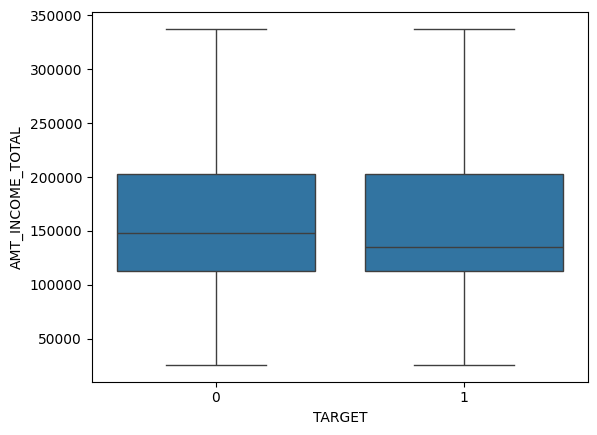

In [ ]:
sns.boxplot(data = application_data, y = 'AMT_INCOME_TOTAL', x = 'TARGET', showfliers = False)

# AMT_CREDIT vs. Target

This look at amount of credit taken out does not provide us with too much useful info. If anything, the loans that people defaulted on tended to be smaller. Perhaps this relates to income.

<Axes: xlabel='TARGET', ylabel='AMT_CREDIT'>

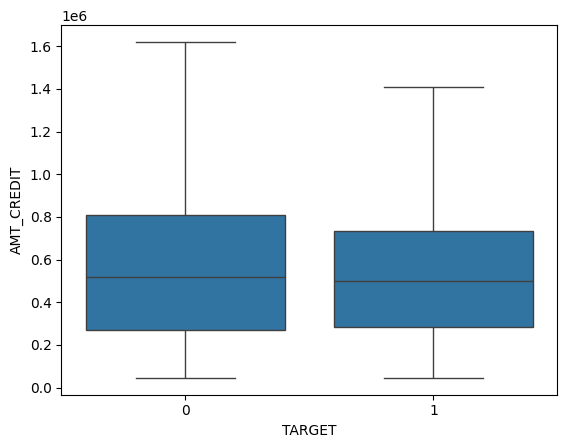

In [ ]:
sns.boxplot(data = application_data, y = 'AMT_CREDIT', x = 'TARGET', showfliers = False)

# AMT_ANNUITY vs. TARGET

Based on this graph, it looks like defaulters faced a slightly higher median annuity. Overall, their annuities tended to be lower though, again perhaps related to income.

<Axes: xlabel='TARGET', ylabel='AMT_ANNUITY'>

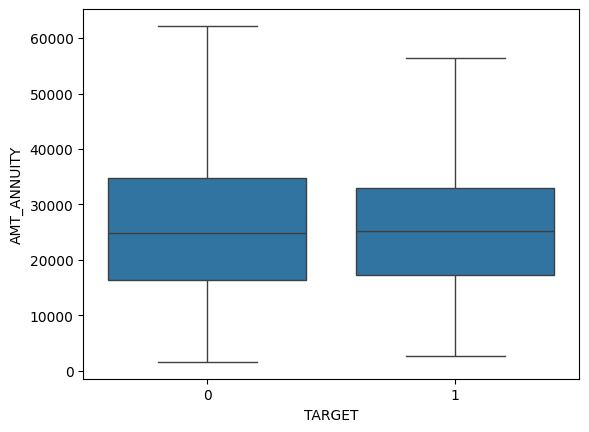

In [ ]:
sns.boxplot(data = application_data, y = 'AMT_ANNUITY', x = 'TARGET', showfliers = False)

# income_credit_ratio vs. TARGET

We made a box plot of income as a multiple of credit requested ignoring outliers.

General income divided by credit requested does not really seem to impact whether or not you will default, though those who did not default tended to have a higher multiple.

<Axes: xlabel='TARGET', ylabel='income_credit_ratio'>

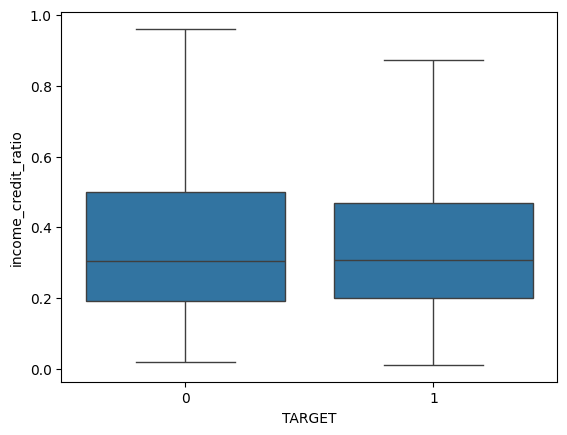

In [ ]:
application_data['income_credit_ratio'] = application_data['AMT_INCOME_TOTAL']/application_data['AMT_CREDIT']
sns.boxplot(data = application_data, y = 'income_credit_ratio', x = 'TARGET', showfliers = False)

# External Source/Credit Score Data

These next three graphs look at what appears to be credit score.

Generally speaking, lower external source scores were correlated with defaulting on the loan.

Assuming these external scores are credit scores from the three credit agencies, this would make a lot of sense that a lower credit rating is associated with a greater likelihood of default.

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_1'>

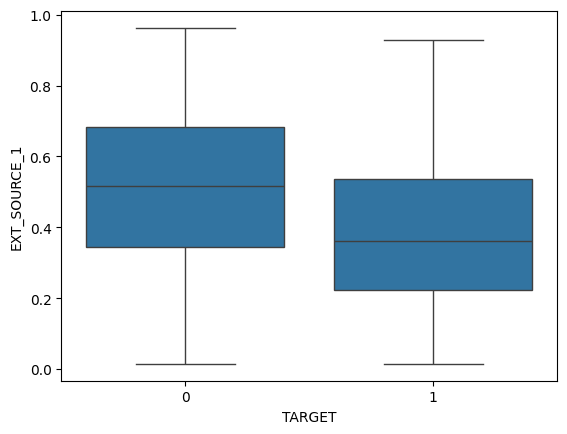

In [ ]:
sns.boxplot(data = application_data, x = 'TARGET', y = 'EXT_SOURCE_1')

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_2'>

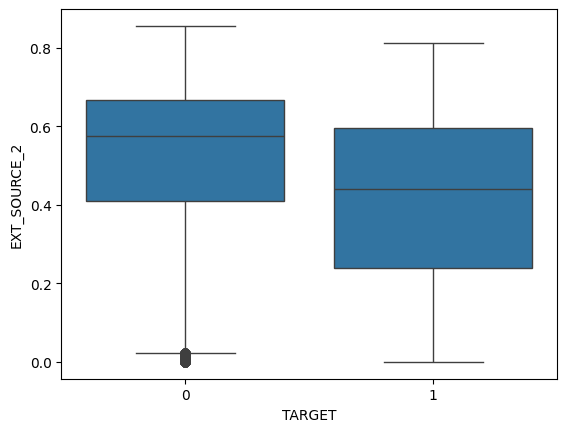

In [ ]:
sns.boxplot(data = application_data, x = 'TARGET', y = 'EXT_SOURCE_2')

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_3'>

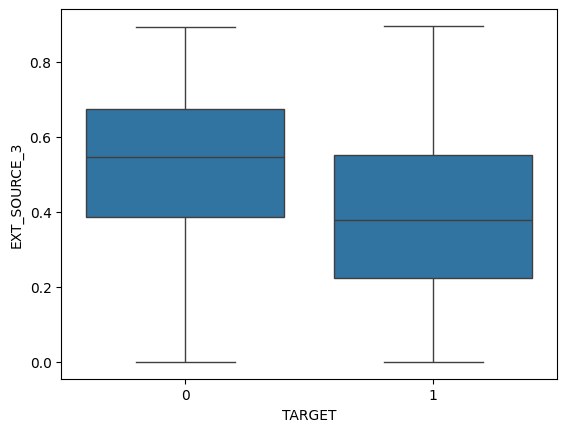

In [ ]:
sns.boxplot(data = application_data, x = 'TARGET', y = 'EXT_SOURCE_3')

# DAYS_EMPLOYED vs. TARGET

It looks like approved applicants tended to have worked for longer.

This makes sense because a more stable job and an older applicant would likely mean more money saved.

<Axes: xlabel='TARGET', ylabel='DAYS_EMPLOYED'>

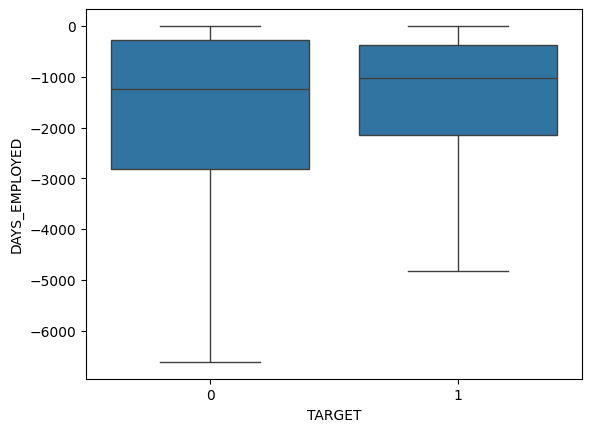

In [ ]:
sns.boxplot(data = application_data, y = 'DAYS_EMPLOYED', x = 'TARGET', showfliers = False)

# Counts of each contract

Applicants applying for cash loans were more likely to default. This makes sense because someone at risk of default is probably not on a revolving credit facility.

<Axes: xlabel='NAME_CONTRACT_TYPE'>

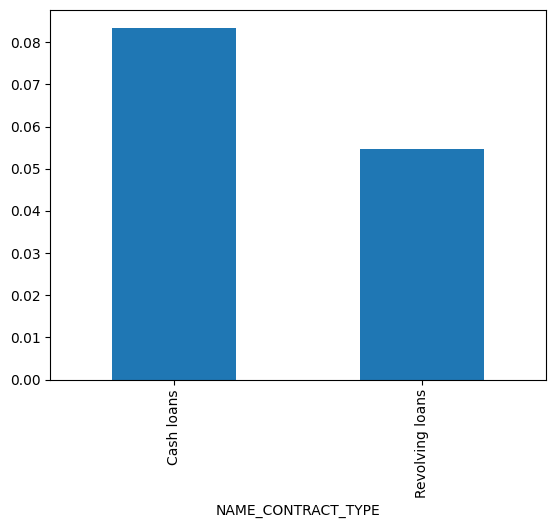

In [ ]:

application_data.groupby(['NAME_CONTRACT_TYPE'])['TARGET'].mean().plot(kind = 'bar')

# Default likelihood by income type

Applicants on maternity leave or who were unemploed were more likely to default.This makes sense becayse there is no real income with these jobs, making them more likely to default on a loan.

<Axes: xlabel='NAME_INCOME_TYPE'>

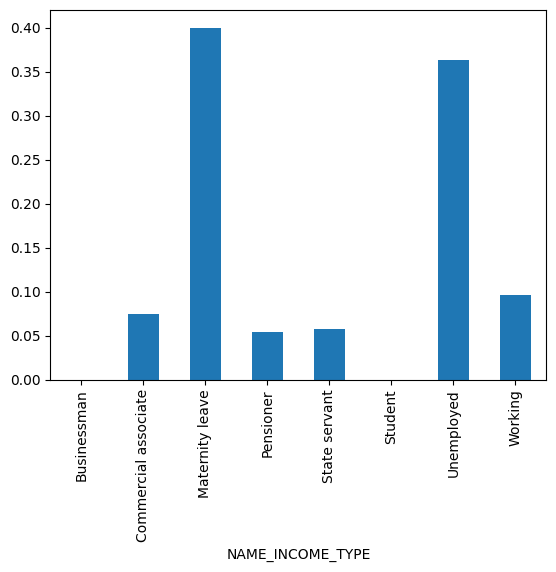

In [ ]:

application_data.groupby(['NAME_INCOME_TYPE'])['TARGET'].mean().plot(kind = 'bar')

# Default likelihood by residence

Applicants in rented apartments or who live with parents were more likely to default. These types of housing are generally associated with less income in general, so this makes sense.

<Axes: xlabel='NAME_HOUSING_TYPE'>

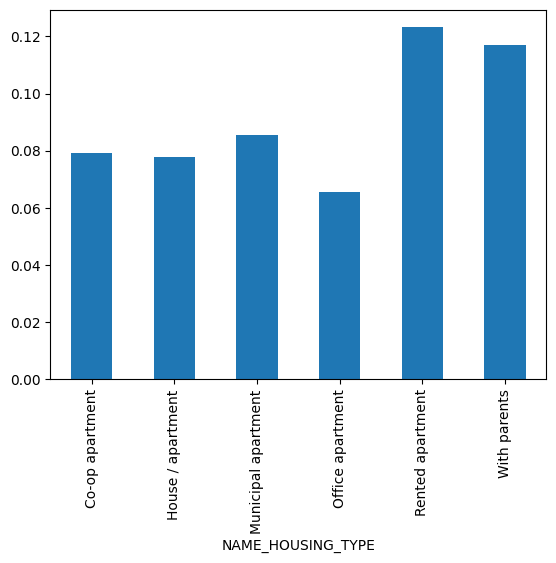

In [ ]:
application_data.groupby(['NAME_HOUSING_TYPE'])['TARGET'].mean().plot(kind = 'bar')

# Number of Defaults

Generally speaking, most people are able to pay off their loans on time, while only some people end up defaulting.

<Axes: xlabel='TARGET'>

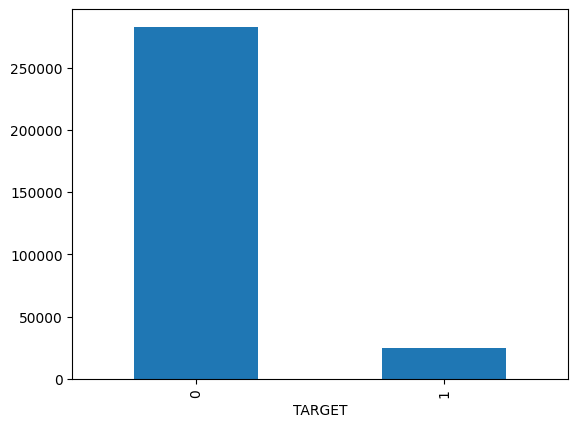

In [ ]:

application_data['TARGET'].value_counts().plot(kind = 'bar')

# Default rate by job type

The more basic, less skillful, and lower paying jobs were more likely to default on their loan.

<Axes: xlabel='OCCUPATION_TYPE'>

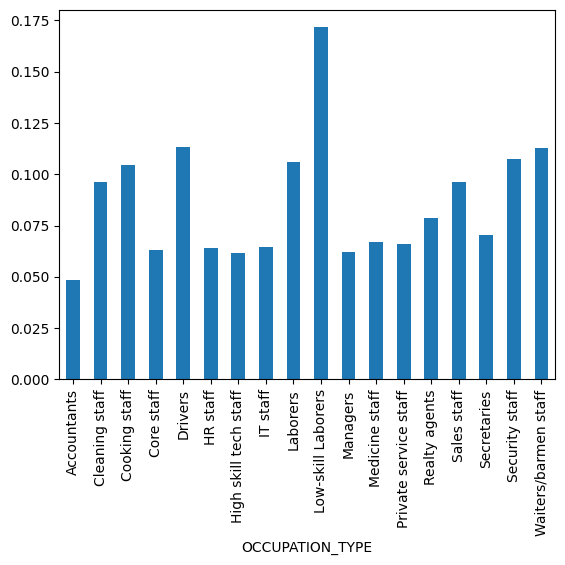

In [ ]:
application_data.groupby(['OCCUPATION_TYPE'])['TARGET'].mean().plot(kind = 'bar')

# City Tier vs. Default Rate

City tier appears to matter a fair bit in determining whether or not they would default. We assume that desireablility is in the order of most to least, as people in less desireable cities would probably be more likely to default on these loans based on how these tiers are probably calculated.

<Axes: xlabel='REGION_RATING_CLIENT_W_CITY'>

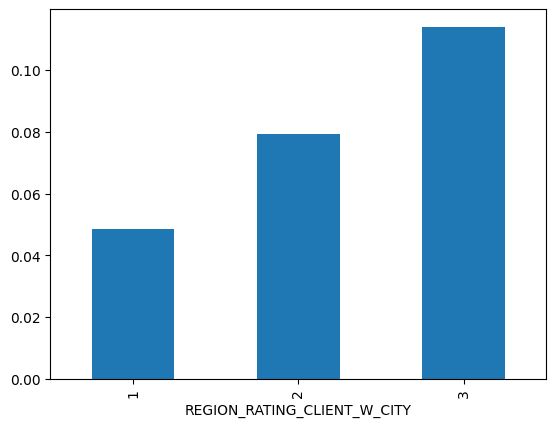

In [ ]:

application_data.groupby(['REGION_RATING_CLIENT_W_CITY'])['TARGET'].mean().plot(kind = 'bar')

# TTM Credit Bureau Requests vs. Target

Typically, those who defaulted had more requests made back to credit bureaus within the past twelve months than those who did not default.


<Axes: xlabel='TARGET', ylabel='AMT_REQ_CREDIT_BUREAU_YEAR'>

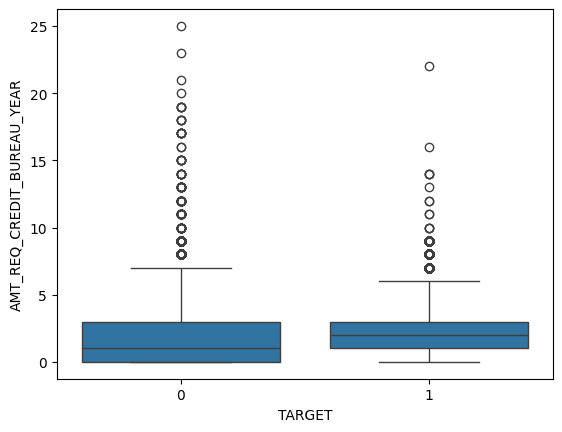

In [ ]:
sns.boxplot(data = application_data, x = 'TARGET', y = 'AMT_REQ_CREDIT_BUREAU_YEAR')

In [ ]:
previous_application.NAME_CONTRACT_STATUS.head()

,NAME_CONTRACT_STATUS
0,Approved
1,Approved
2,Approved
3,Approved
4,Refused


# Merged dataset

We merged the datasets on SK_ID_CURR to match old loan info to current loan info by individual ID.

In [ ]:
merged_df = pd.merge(application_data, previous_application, on='SK_ID_CURR', how='left')

# Previous offer status vs. default rate

Those who were approved on a previous loan were less likely to default than those who were cancelled, who were less likely to default than those who were refused.

<Axes: xlabel='NAME_CONTRACT_STATUS'>

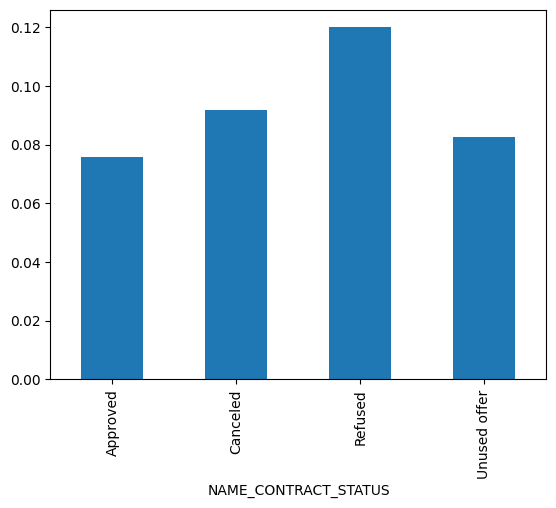

In [ ]:
merged_df.groupby(['NAME_CONTRACT_STATUS'])['TARGET'].mean().plot(kind = 'bar')

# Tracy's Section: 4+ New Graphs w/ Interpretation

# Data Cleaning
Eliminate columns that are too empty to be used.


In [9]:
null_pct = application_data.isnull().sum() / len(application_data) * 100
print(null_pct[null_pct > 40])

OWN_CAR_AGE                     65.987812
EXT_SOURCE_1                    56.263926
APARTMENTS_AVG                  50.860867
BASEMENTAREA_AVG                58.597381
YEARS_BEGINEXPLUATATION_AVG     48.868286
YEARS_BUILD_AVG                 66.522562
COMMONAREA_AVG                  69.928411
ELEVATORS_AVG                   53.373150
ENTRANCES_AVG                   50.441285
FLOORSMAX_AVG                   49.852134
FLOORSMIN_AVG                   67.885480
LANDAREA_AVG                    59.420919
LIVINGAPARTMENTS_AVG            68.413864
LIVINGAREA_AVG                  50.296022
NONLIVINGAPARTMENTS_AVG         69.464845
NONLIVINGAREA_AVG               55.260401
APARTMENTS_MODE                 50.860867
BASEMENTAREA_MODE               58.597381
YEARS_BEGINEXPLUATATION_MODE    48.868286
YEARS_BUILD_MODE                66.522562
COMMONAREA_MODE                 69.928411
ELEVATORS_MODE                  53.373150
ENTRANCES_MODE                  50.441285
FLOORSMAX_MODE                  49

# Age vs. Target
For Females (F), the median age for those who repay is approximately 45, but it drops to roughly 40 for those who default.

For Males (M), the median age for repayment is roughly 41, dropping to approximately 38 for those who default.

Text(0.5, 1.0, 'Defaulting vs. Repaying Applicants by Age')

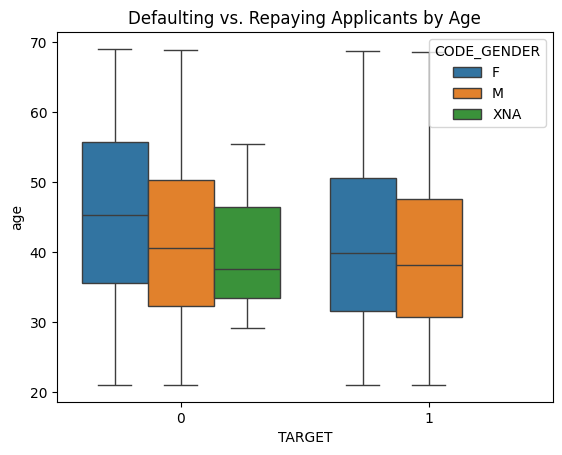

In [16]:
application_data['age'] = application_data['DAYS_BIRTH'] / -365
application_data.groupby(['CODE_GENDER','TARGET'])['age'].mean()
sns.boxplot(data=application_data, x='TARGET', y='age', hue='CODE_GENDER')
plt.title('Defaulting vs. Repaying Applicants by Age')

# Education level vs. Target

Text(0.5, 1.0, 'Average Default Rate by Income Type')

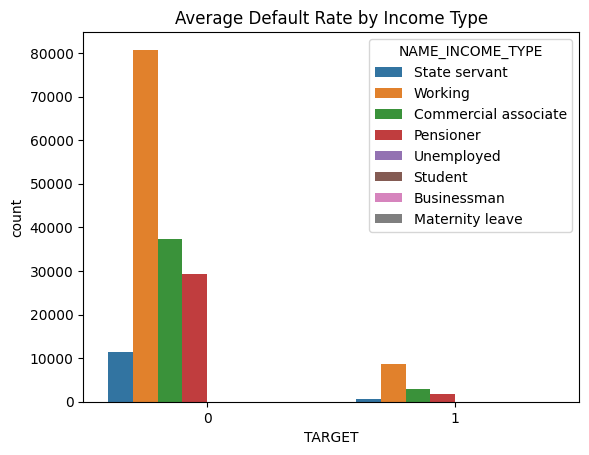

In [14]:
sns.countplot(data=application_data, x='TARGET', hue = 'NAME_INCOME_TYPE')
plt.title('Average Default Rate by Income Type')

# Account History vs. Target Mean
To just identify or flag people who have previous applications and look at their default conditions.

Text(0, 0.5, 'Mean of TARGET (Default Rate)')

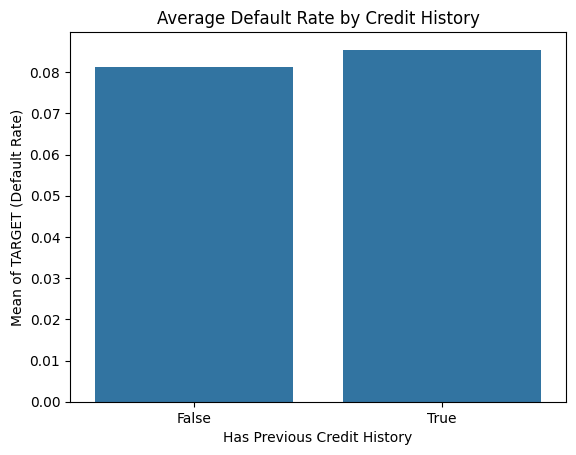

In [13]:
history_mean = application_data.groupby('has_history')['TARGET'].mean().reset_index()
sns.barplot(data=history_mean, x='has_history', y='TARGET')
plt.title('Average Default Rate by Credit History')
plt.xlabel('Has Previous Credit History')
plt.ylabel('Mean of TARGET (Default Rate)')

# Mais's Section: 4+ New Graphs w/ Interpretation

<Axes: xlabel='CODE_GENDER'>

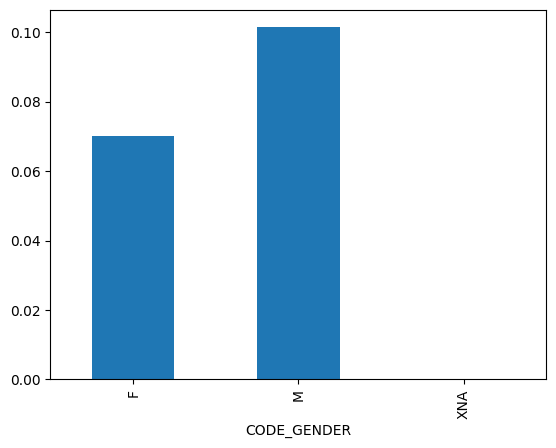

In [ ]:
application_data.groupby(['CODE_GENDER'])['TARGET'].mean().plot(kind = 'bar')

In [ ]:
application_data.groupby('CNT_CHILDREN')['TARGET'].agg(['mean', 'count'])

,mean,count
CNT_CHILDREN,,
0,0.077118,215371
1,0.089236,61119
2,0.087218,26749
3,0.096314,3717
4,0.128205,429
5,0.083333,84
6,0.285714,21
7,0.000000,7
8,0.000000,2


<Axes: xlabel='NAME_EDUCATION_TYPE'>

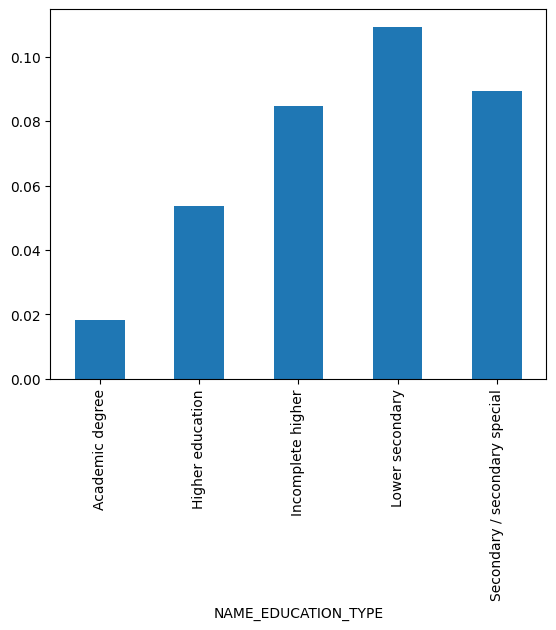

In [ ]:
application_data.groupby(['NAME_EDUCATION_TYPE'])['TARGET'].mean().plot(kind = 'bar')

<Axes: xlabel='TARGET', ylabel='DAYS_BIRTH'>

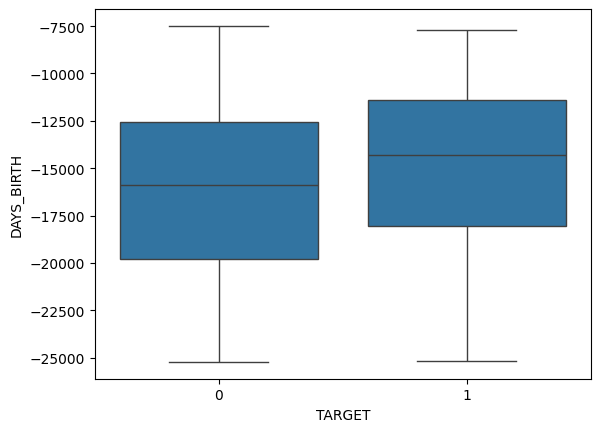

In [ ]:
sns.boxplot(data = application_data, x = 'TARGET', y = 'DAYS_BIRTH')

# Ben's Section: 4+ New Graphs w/ Interpretation

# Code Reject Reason vs. Mean Target/Missed Payment Rate


Based on the graph, SCOFR, Secured Overnight Financing Rate was cited as the most prevalent reason for a previous loan to be denied that then led to missing payments on the current loan.

For a reason of rejection, SCOFR means that the bank cannot provide the loan (often a variable rate mortgage) at a rate at which the client can reasonably afford or would be willing to pay. Either the client has poor credit history, insufficient income, insufficient collateral, or simply does not want to pay the rate which was provided. Much of this ties to economic instability that would in turn translate to a logically hihger likelihood of defaulting on future approved loans.

<Axes: xlabel='CODE_REJECT_REASON'>

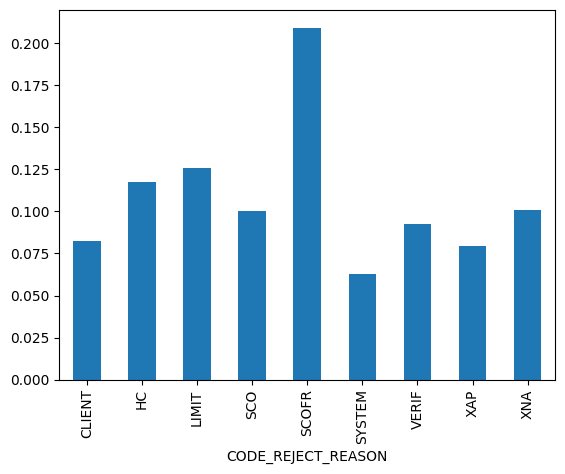

In [ ]:
merged_df.groupby(['CODE_REJECT_REASON'])['TARGET'].mean().plot(kind = 'bar')

# Previous Loan Type vs. Target Mean by Income

To break down the classifications:

Cards = Credit Card payments

Cars = Auto loans

Cash = Traditional cash loan

POS = Point of sale loan (Klarna perhaps)

While lower earners later faced payment difficulty having had dapplied for cash or credit card loans in the past, wealthier individuals did not face the same degree of specificity when it came to the predictive value of these variables, other than there lesser likelihood to face future payment difficulty having taken out a POS loan.

<Axes: xlabel='NAME_PORTFOLIO'>

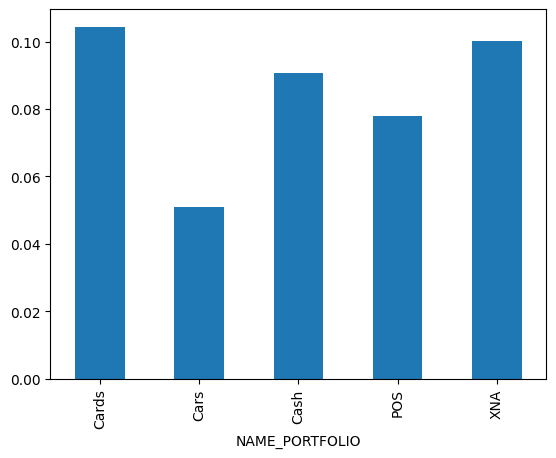

In [ ]:
# For the bottom 90% of earners
merged_df.query("AMT_INCOME_TOTAL < AMT_INCOME_TOTAL.quantile(0.9)").groupby(['NAME_PORTFOLIO'])['TARGET'].mean().plot(kind = 'bar')

<Axes: xlabel='NAME_PORTFOLIO'>

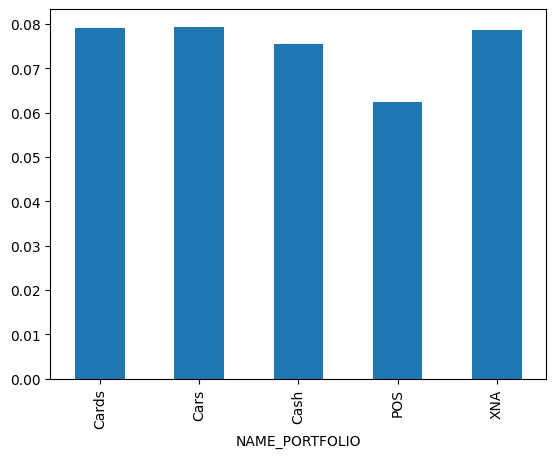

In [ ]:
# For the top 10% of earners
merged_df.query("AMT_INCOME_TOTAL > AMT_INCOME_TOTAL.quantile(0.90)").groupby(['NAME_PORTFOLIO'])['TARGET'].mean().plot(kind = 'bar')

# Previous Loan Purpose vs. Mean Target

Hobby loans, money for a third party, and car repairs seemed to be the strongest predictors of future payment difficuly.

Hobby loans could make sense if the hobby does not generate any real income, so the individual would be sinking the principle into something without return.

For money for a third party, it is clear that the client engages in riskier behavior, which would be a predictor of future payment difficulty.

Finally, loans for car repairs would again be a cost that does not really lead to any real value for the client, again making it logical to be a predictor of future payment difficulty.


<Axes: xlabel='NAME_CASH_LOAN_PURPOSE'>

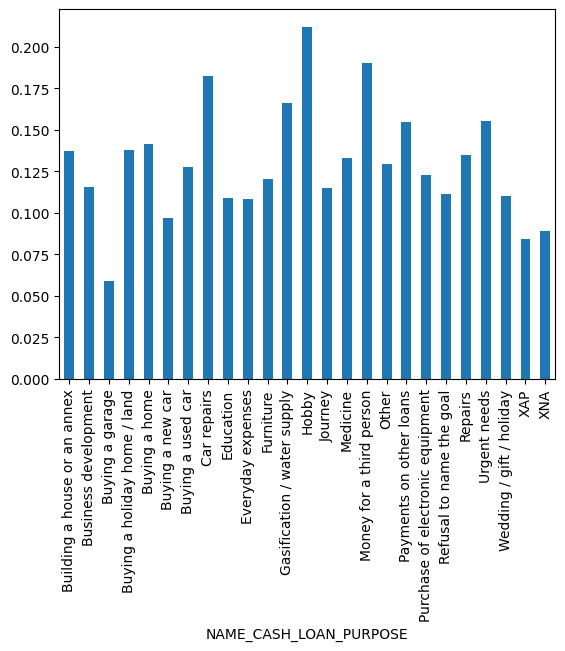

In [ ]:
merged_df.query("AMT_INCOME_TOTAL < AMT_INCOME_TOTAL.quantile(0.9)").groupby(['NAME_CASH_LOAN_PURPOSE'])['TARGET'].mean().plot(kind = 'bar')